In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from targetree import CART
from targetree.tree_vis import plot_cart_tree
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
EXAMPLES_DIR = PROJECT_ROOT / "examples"
DATA_DIR = EXAMPLES_DIR / "data"

### 1. diabetes

In [2]:
df_diabetes = pd.read_csv(DATA_DIR / "diabetes.csv")

In [3]:
y1 = np.array(df_diabetes['Outcome'])
X1 = np.array(df_diabetes.drop(['Outcome'],axis=1))

In [4]:
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
cut = 0.6
max_depth = 2

[Glucose <= 127.5000]
  [Age <= 28.5000]
    Leaf: mean=0.085, n=271
    Leaf: mean=0.332, n=214
  [BMI <= 29.9500]
    Leaf: mean=0.316, n=76
    Leaf: mean=0.725, n=207


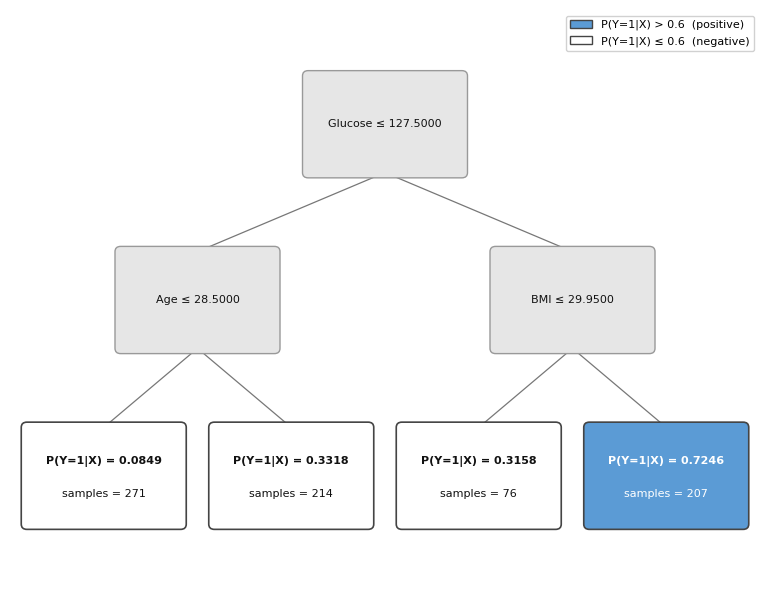

In [6]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.02, lbd=0, cut=cut, method = 'cart',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

[Glucose <= 127.5000]
  [Age <= 21.5000]
    Leaf: mean=0.040, n=50
    Leaf: mean=0.211, n=435
  [BMI <= 29.9500]
    Leaf: mean=0.316, n=76
    Leaf: mean=0.725, n=207


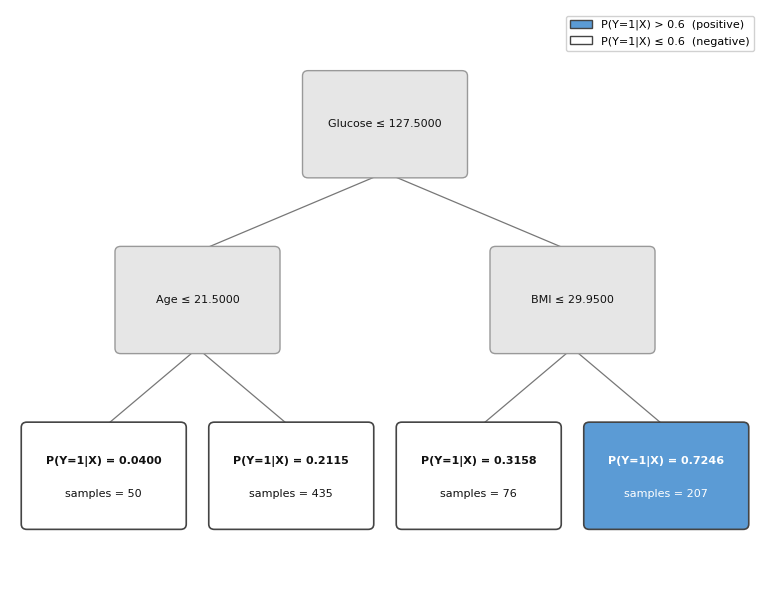

In [7]:
# mdfs
model = CART(depth=max_depth, minimum_portion=0.02, lbd=1, cut=cut, method = 'pfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

In [8]:
cut = 0.6
max_depth = 2

In [9]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X1, y1)
phat = rf.predict_proba(X1)[:,1]

[Glucose <= 127.5000]
  [Age <= 28.5000]
    Leaf: mean=0.098, n=271
    Leaf: mean=0.335, n=214
  [BMI <= 29.9500]
    Leaf: mean=0.340, n=76
    Leaf: mean=0.700, n=207


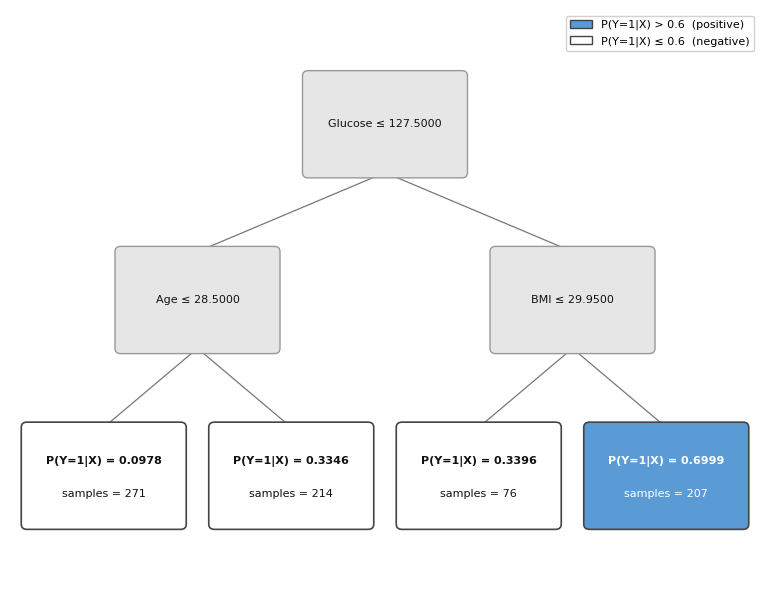

In [10]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.03, cut=cut, method = 'cart',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1, phat)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

[Glucose <= 127.5000]
  [Age <= 21.5000]
    Leaf: mean=0.055, n=50
    Leaf: mean=0.219, n=435
  [BMI <= 29.9500]
    Leaf: mean=0.340, n=76
    Leaf: mean=0.700, n=207


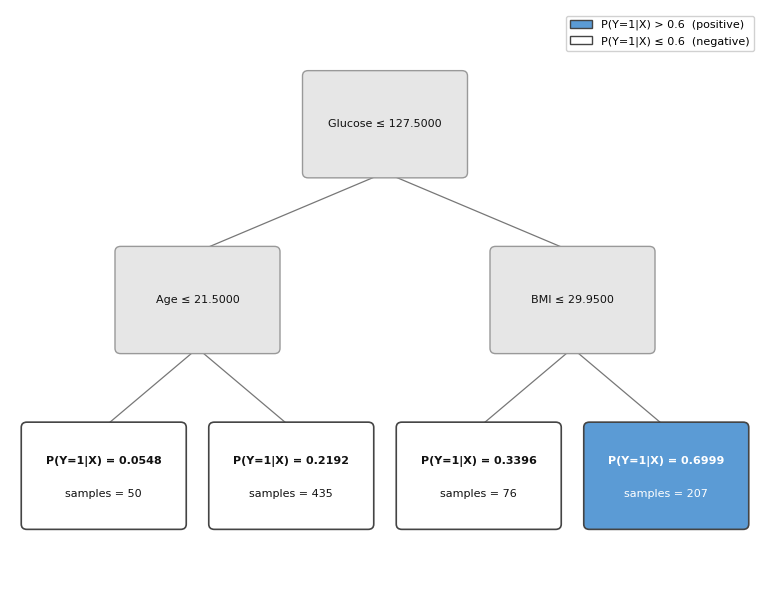

In [11]:
###### mdfs ######
model = CART(depth=max_depth, minimum_portion=0.03, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1, phat)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

### 2. forestfires

In [12]:
df_forestfires = pd.read_csv(DATA_DIR / "forestfires.csv")
df_forestfires['month_num'] = df_forestfires['month'].map(
    {'jan': 1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9,'oct':10,'nov':11,'dec':12})

In [13]:
y1 = np.array(1*(df_forestfires['area']>5))
X1 = np.array(df_forestfires.drop(['month', 'day','area','month_num'],axis=1))

In [14]:
df_forestfires_ = df_forestfires.drop(['month', 'day','area','month_num'],axis=1)

In [15]:
cut = 1/3
max_depth = 3

In [16]:
# df_forestfires_

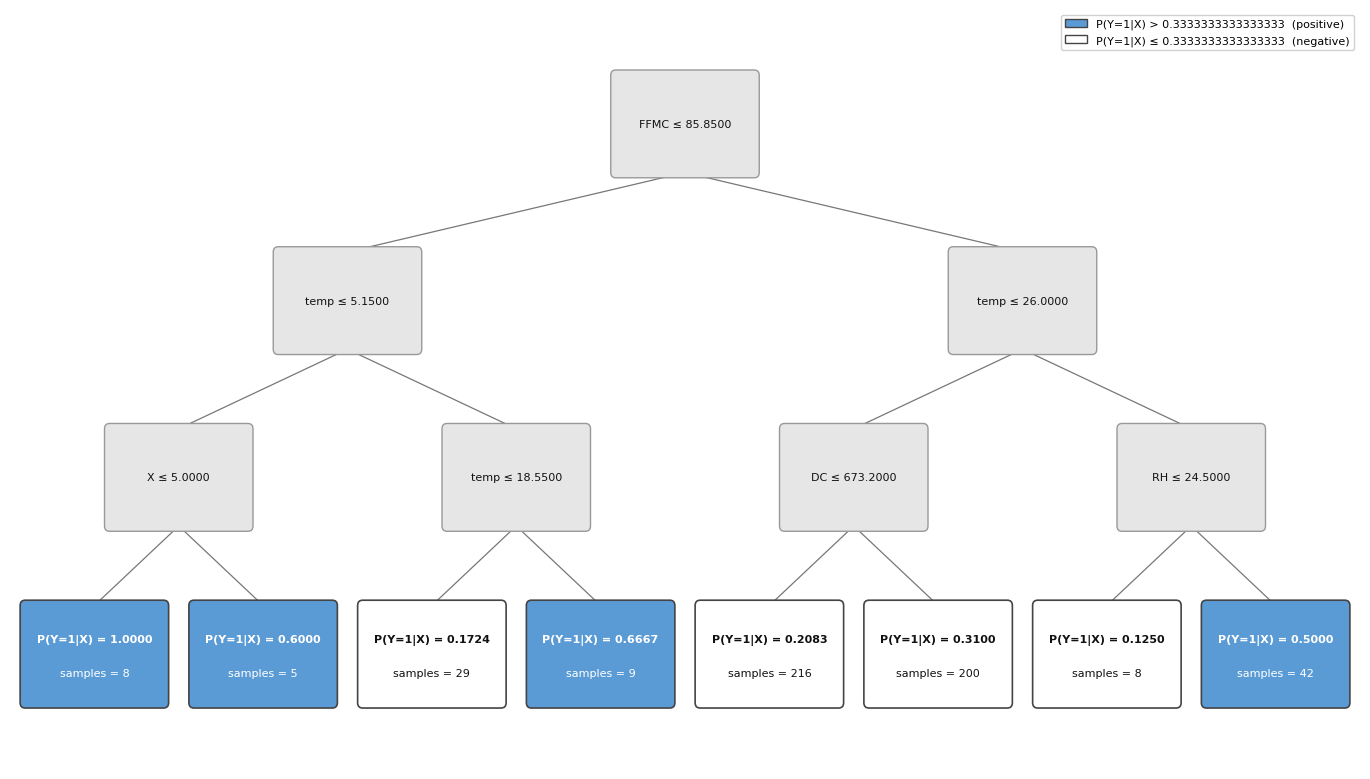

In [17]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.02, cut=cut, method = 'cart',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)


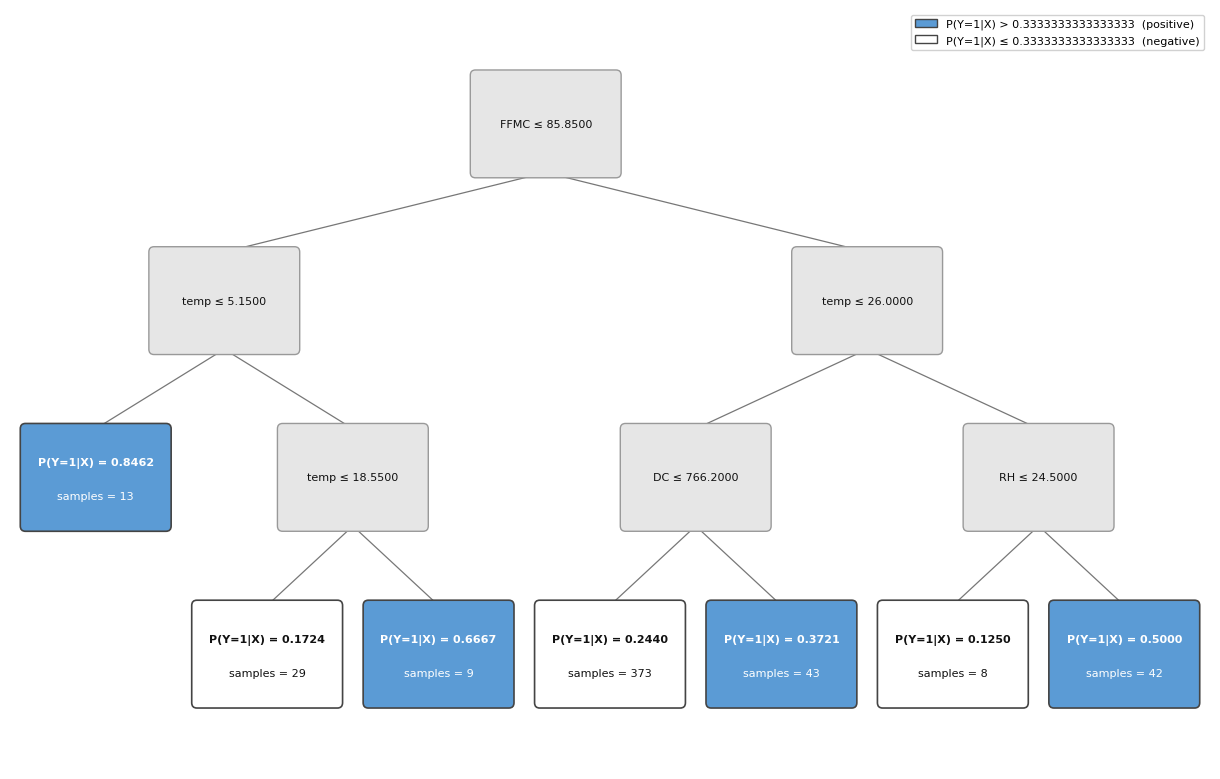

In [18]:
# mdfs
model = CART(depth=max_depth, minimum_portion=0.02, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

In [19]:
cut = 1/3
max_depth = 3

In [20]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X1, y1)
phat = rf.predict_proba(X1)[:,1]

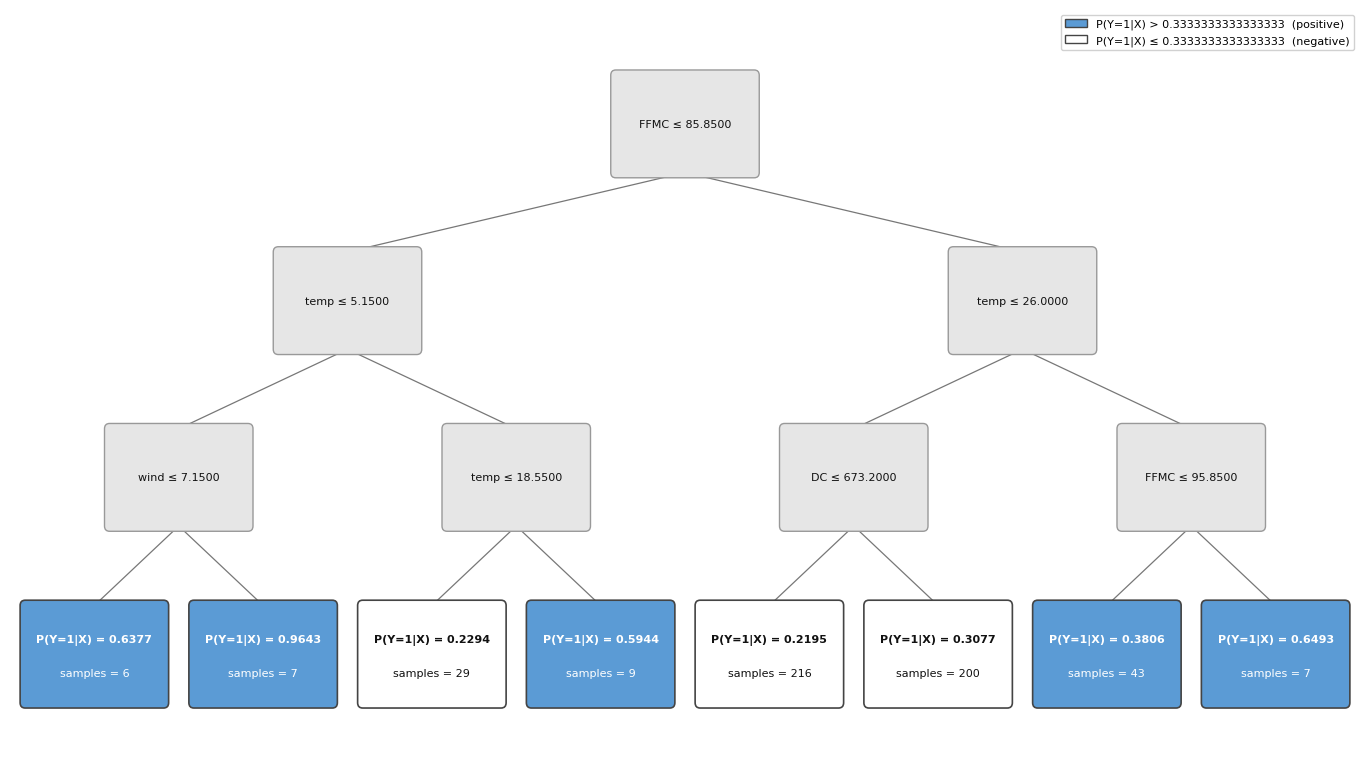

In [21]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.02,cut=cut, method = 'cart',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1, phat)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

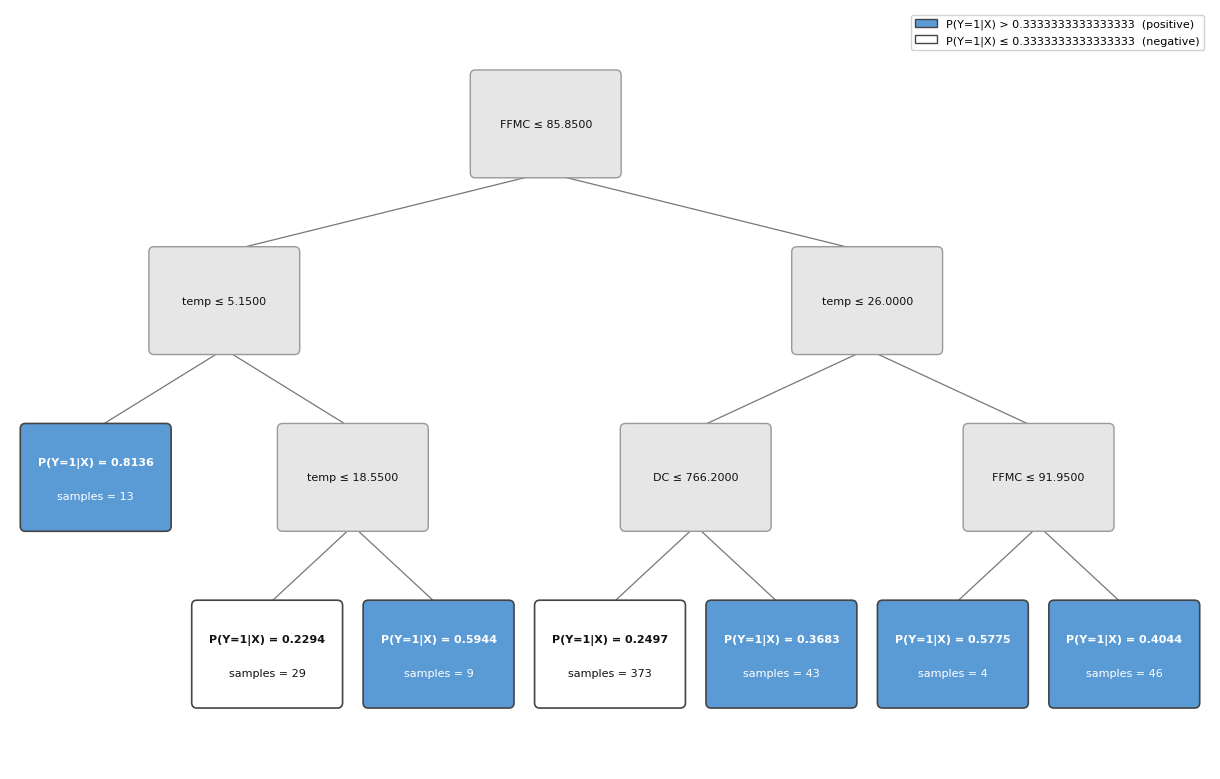

In [22]:
###### mdfs ######
model = CART(depth=max_depth, minimum_portion=0.02, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1, phat)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

In [23]:
df_eligible = pd.read_csv(EXAMPLES_DIR / "datasets" / "eligible.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/wanglei/Documents/ChatGPT/Targetree/examples/datasets/eligible.csv'

In [ ]:
df_eligible = pd.concat([df_eligible, pd.get_dummies(df_eligible['race'])*1],axis=1).drop(['Unnamed: 0','race'],axis=1).drop_duplicates()
y = np.array(df_eligible['WIC_1'])
X = np.array(df_eligible.drop(['WIC_1'],axis=1))

In [ ]:
cut = 1/2
max_depth = 3

In [ ]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X, y)
phat = rf.predict_proba(X)[:,1]

In [ ]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.05,cut=cut, method = 'cart',feature_name = np.array(df_eligible.columns[1:]))
model.fit(X, y)
model.print_tree()

In [ ]:
###### mdfs ######
model = CART(depth=max_depth, minimum_portion=0.05, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_eligible.columns[1:]))
model.fit(X, y)
model.print_tree()

In [ ]:
###### wefs ######
model = CART(depth=max_depth, minimum_portion=0.05, lbd=1, cut=cut, method = 'ermfs',feature_name = np.array(df_eligible.columns[1:]))
model.fit(X, y)
model.print_tree()

In [ ]:
df_donation = pd.read_csv(EXAMPLES_DIR / "datasets" / "donation.csv")

In [ ]:
y = np.array(df_donation['gave'])
X = np.array(df_donation.drop(['gave'],axis=1))

In [ ]:
cut = 0.05
max_depth = 3

In [ ]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X, y)
phat = rf.predict_proba(X)[:,1]

In [ ]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.05,cut=cut, method = 'cart',feature_name = np.array(df_donation.columns[1:]))
model.fit(X, y)
model.print_tree()

In [ ]:
###### mdfs ######
model = CART(depth=max_depth, minimum_portion=0.05, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_donation.columns[1:]))
model.fit(X, y)
model.print_tree()

In [ ]:
###### wefs ######
model = CART(depth=max_depth, minimum_portion=0.05, lbd=1, cut=cut, method = 'ermfs',feature_name = np.array(df_donation.columns[1:]))
model.fit(X, y)
model.print_tree()